# Data Understanding

Fase 2 del proceso CRISP-DM. El objetivo de este notebook es conocer la estructura, calidad y distribución de los datos antes de construir ningún modelo. Cada análisis incluye su interpretación y, cuando corresponde, una decisión concreta sobre cómo tratar ese dato en la fase de preparación.

1. Conexión y carga de datos

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from dotenv import load_dotenv
from IPython.display import display

sns.set_theme(style='whitegrid')
load_dotenv()

def get_engine():
    user = os.getenv('POSTGRES_USER', 'nba_user')
    pw   = os.getenv('POSTGRES_PASSWORD', 'nba_pass')
    host = os.getenv('POSTGRES_HOST', 'localhost')
    port = os.getenv('POSTGRES_PORT', '5432')
    db   = os.getenv('POSTGRES_DB',   'nba_database')
    return create_engine(f'postgresql+psycopg2://{user}:{pw}@{host}:{port}/{db}')

engine = get_engine()

team_logs     = pd.read_sql('SELECT * FROM fact_team_game_logs',      engine)
player_logs   = pd.read_sql('SELECT * FROM fact_player_game_logs',    engine)
team_season   = pd.read_sql('SELECT * FROM fact_team_season_stats',   engine)
player_season = pd.read_sql('SELECT * FROM fact_player_season_stats', engine)

## Descripción general de los datos

In [2]:
pd.DataFrame({
    'filas':    [len(team_logs), len(player_logs), len(team_season), len(player_season)],
    'columnas': [team_logs.shape[1], player_logs.shape[1],
                 team_season.shape[1], player_season.shape[1]]
}, index=['team_logs', 'player_logs', 'team_season', 'player_season'])

,filas,columnas
team_logs,2460,15
player_logs,26651,17
team_season,30,16
player_season,582,14


In [3]:
display(team_logs.dtypes.rename('tipo').to_frame())
team_logs.head(3)

,tipo
game_id,str
team_id,int64
game_date,datetime64[us]
matchup,str
wl,str
pts,int64
reb,int64
ast,int64
stl,int64
blk,int64


,game_id,team_id,game_date,matchup,wl,pts,reb,ast,stl,blk,tov,fg_pct,fg3_pct,ft_pct,plus_minus
0,0022501192,1610612761,2026-04-12,TOR vs. BKN,W,136,43,36,9,8,10.0,0.638,0.444,0.759,35.0
1,0022501196,1610612756,2026-04-12,PHX @ OKC,W,135,54,28,5,8,13.0,0.554,0.488,0.500,32.0
2,0022501194,1610612745,2026-04-12,HOU vs. MEM,W,132,64,23,10,8,11.0,0.457,0.286,0.733,31.0


`fact_team_game_logs` tiene 2.460 registros: uno por equipo por partido disputado, cubriendo los 82 partidos de los 30 equipos de la temporada regular 2025-26. Es la tabla principal para el problema de clasificación. La columna `wl` es la variable objetivo y las columnas estadísticas son los candidatos directos a features.

In [4]:
display(player_logs.dtypes.rename('tipo').to_frame())
player_logs.head(3)

,tipo
game_id,str
player_id,int64
team_id,int64
game_date,datetime64[us]
matchup,str
wl,str
min,float64
pts,int64
reb,int64
ast,int64


,game_id,player_id,team_id,game_date,matchup,wl,min,pts,reb,ast,stl,blk,tov,fg_pct,fg3_pct,ft_pct,plus_minus
0,0022501195,1642852,1610612740,2026-04-12,NOP @ MIN,L,41.053333,30,22,4,1,1,4,0.393,0.5,0.875,-5
1,0022501195,1642847,1610612740,2026-04-12,NOP @ MIN,L,41.383333,36,10,5,2,1,2,0.429,0.0,0.857,0
2,0022501196,1642382,1610612760,2026-04-12,OKC vs. PHX,L,42.233333,26,10,1,2,5,1,0.500,0.5,0.500,-18


`fact_player_game_logs` tiene 26.651 registros: uno por jugador por partido en que tuvo minutos. Es la tabla base para el problema de regresión. La columna `pts` es la variable objetivo. La columna `min` está almacenada como minutos decimales (`float64`), no como texto, por lo que no requiere parseo adicional.

In [5]:
display(team_season.dtypes.rename('tipo').to_frame())
display(team_season.head(3))
display(player_season.dtypes.rename('tipo').to_frame())
player_season.head(3)

,tipo
team_id,int64
team_name,str
gp,int64
w,int64
l,int64
w_pct,float64
pts,float64
reb,float64
ast,float64
stl,float64


,team_id,team_name,gp,w,l,w_pct,pts,reb,ast,stl,blk,tov,fg_pct,fg3_pct,ft_pct,season
0,1610612737,Atlanta Hawks,82,46,36,0.561,118.5,43.5,30.1,9.4,4.7,14.2,0.474,0.371,0.774,2025-26
1,1610612738,Boston Celtics,82,56,26,0.683,114.9,46.4,24.6,7.1,5.0,12.4,0.467,0.367,0.807,2025-26
2,1610612751,Brooklyn Nets,82,20,62,0.244,105.9,39.3,25.0,8.0,4.3,15.8,0.443,0.340,0.780,2025-26


,tipo
player_id,int64
player_name,str
team_abbrev,str
gp,int64
pts,float64
reb,float64
ast,float64
stl,float64
blk,float64
tov,float64


,player_id,player_name,team_abbrev,gp,pts,reb,ast,stl,blk,tov,fg_pct,fg3_pct,ft_pct,season
0,1630639,A.J. Lawson,TOR,24,4.2,1.8,0.3,0.5,0.2,0.3,0.436,0.422,0.778,2025-26
1,1631260,AJ Green,MIL,78,10.4,2.7,1.9,0.5,0.1,1.0,0.424,0.419,0.855,2025-26
2,1642358,AJ Johnson,DAL,48,3.3,1.1,1.0,0.2,0.1,0.6,0.324,0.211,0.850,2025-26


`fact_team_season_stats` (30 filas) y `fact_player_season_stats` (582 filas) contienen las estadísticas acumuladas de la temporada. No se usan directamente como datos de entrenamiento, pero sirven como referencia para validar que los features construidos desde los game logs son coherentes con los promedios reales de la temporada.

## Análisis de calidad de datos

In [6]:
pd.DataFrame([
    {'tabla': name, 'filas': len(df), 'nulos_totales': int(df.isnull().sum().sum())}
    for name, df in [('team_logs', team_logs), ('player_logs', player_logs),
                     ('team_season', team_season), ('player_season', player_season)]
]).set_index('tabla')

,filas,nulos_totales
tabla,,
team_logs,2460,0
player_logs,26651,0
team_season,30,0
player_season,582,0


In [7]:
pd.Series({
    'team_logs':     team_logs.duplicated(['game_id', 'team_id']).sum(),
    'player_logs':   player_logs.duplicated(['game_id', 'player_id']).sum(),
    'team_season':   team_season.duplicated(['team_id', 'season']).sum(),
    'player_season': player_season.duplicated(['player_id', 'season']).sum()
}, name='duplicados').to_frame()

,duplicados
team_logs,0
player_logs,0
team_season,0
player_season,0


In [8]:
pd.Series({
    'player pts < 0':    (player_logs['pts'] < 0).sum(),
    'player reb < 0':    (player_logs['reb'] < 0).sum(),
    'player fg_pct > 1': (player_logs['fg_pct'] > 1).sum(),
    'team fg_pct > 1':   (team_logs['fg_pct'] > 1).sum()
}, name='anomalias').to_frame()

,anomalias
player pts < 0,0
player reb < 0,0
player fg_pct > 1,0
team fg_pct > 1,0


Los cuatro datasets no contienen valores nulos ni duplicados. Los datos provienen directamente de la NBA Stats API y cubren la temporada completa sin huecos. Los rangos lógicos son correctos: no hay puntos negativos ni porcentajes superiores a 1. Los datos pueden pasar directamente a la fase de preparación sin limpieza estructural previa.

## Estadísticas descriptivas

In [9]:
num_cols = ['pts', 'reb', 'ast', 'stl', 'blk', 'tov',
            'fg_pct', 'fg3_pct', 'ft_pct', 'plus_minus']
player_logs[num_cols].describe().round(3)

,pts,reb,ast,stl,blk,tov,fg_pct,fg3_pct,ft_pct,plus_minus
count,26651.000,26651.000,26651.000,26651.000,26651.000,26651.000,26651.000,26651.000,26651.000,26651.000
mean,10.671,4.040,2.468,0.777,0.447,1.273,0.438,0.267,0.431,0.000
std,8.650,3.317,2.561,0.990,0.807,1.388,0.252,0.288,0.435,11.939
min,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,-60.000
25%,4.000,2.000,1.000,0.000,0.000,0.000,0.300,0.000,0.000,-8.000
50%,9.000,3.000,2.000,0.000,0.000,1.000,0.455,0.250,0.500,0.000
75%,16.000,6.000,4.000,1.000,1.000,2.000,0.588,0.500,1.000,7.000
max,83.000,25.000,23.000,8.000,9.000,10.000,1.000,1.000,1.000,52.000


In [10]:
num_cols = ['pts', 'reb', 'ast', 'stl', 'blk', 'tov',
            'fg_pct', 'fg3_pct', 'ft_pct', 'plus_minus']
team_logs[num_cols].describe().round(3)

,pts,reb,ast,stl,blk,tov,fg_pct,fg3_pct,ft_pct,plus_minus
count,2460.000,2460.000,2460.000,2460.000,2460.000,2460.000,2460.000,2460.000,2460.000,2460.000
mean,115.608,43.769,26.741,8.420,4.841,14.510,0.472,0.359,0.782,0.000
std,12.915,6.860,5.252,3.143,2.455,4.053,0.055,0.079,0.097,16.501
min,66.000,20.000,10.000,0.000,0.000,3.000,0.291,0.120,0.333,-55.000
25%,107.000,39.000,23.000,6.000,3.000,12.000,0.433,0.306,0.722,-11.000
50%,115.000,44.000,26.000,8.000,5.000,14.000,0.469,0.361,0.788,0.000
75%,125.000,48.000,30.000,10.000,6.000,17.000,0.510,0.410,0.852,11.000
max,157.000,69.000,49.000,20.000,15.000,29.000,0.667,0.655,1.000,55.000


El promedio de puntos por partido a nivel jugador es de 10.7, con una desviación estándar de 8.6. La mediana de 9 puntos es inferior a la media, lo que confirma el sesgo positivo de la distribución: hay una masa de jugadores de rotación baja con 4-8 puntos por partido y unos pocos titulares de alto uso que elevan el promedio. A nivel equipo, la media de 115.6 puntos con desviación de 12.9 refleja el ritmo ofensivo moderno de la liga.

`ft_pct` y `fg3_pct` tienen medias de 0.43 y 0.27 respectivamente. Estos valores están comprimidos a la baja porque incluyen partidos en que el jugador no intentó tiros de esa categoría, que generan un valor de 0. Al construir features de promedio móvil, será más informativo calcular el porcentaje solo sobre partidos en que el jugador efectivamente intentó tiros de esa zona.

`plus_minus` tiene media exactamente 0 y desviación de 11.9. Esto es correcto por construcción: la suma de plus/minus de todos los jugadores en un partido siempre es cero.

## Distribuciones

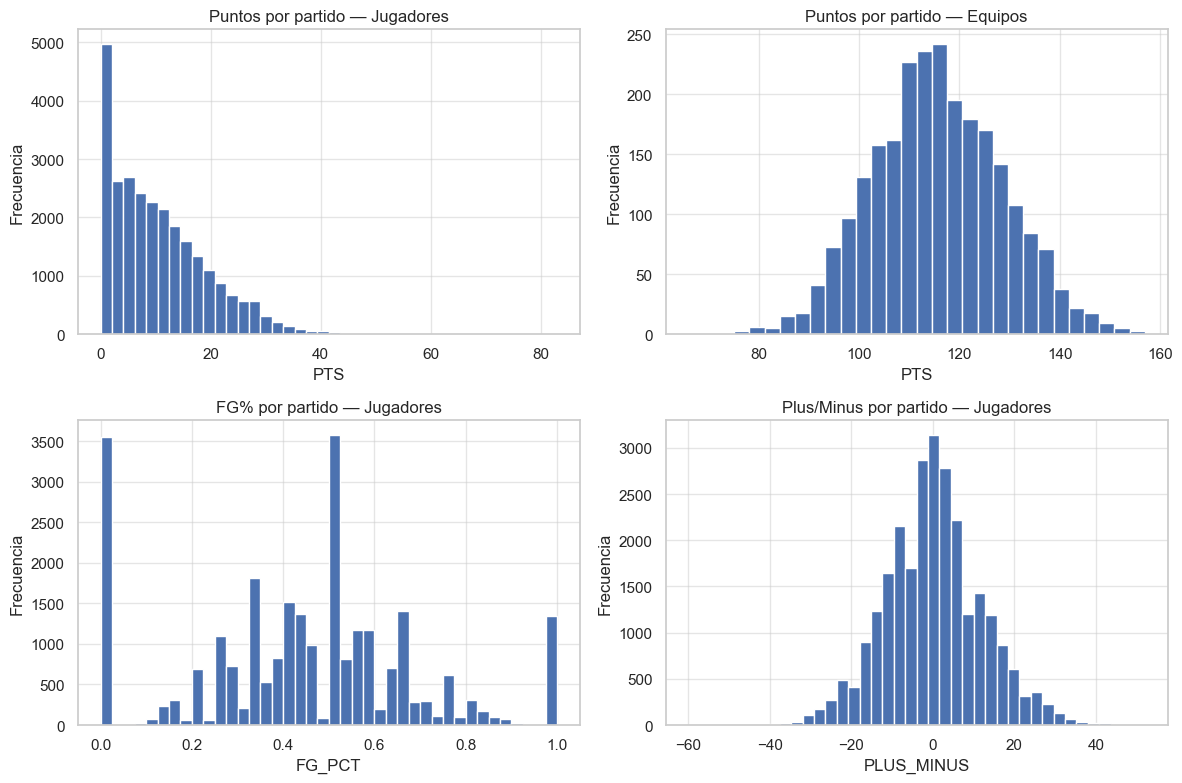

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

player_logs['pts'].hist(bins=40, ax=axes[0, 0], color='#4C72B0', edgecolor='white')
axes[0, 0].set_title('Puntos por partido — Jugadores')
axes[0, 0].set_xlabel('PTS')
axes[0, 0].set_ylabel('Frecuencia')

team_logs['pts'].hist(bins=30, ax=axes[0, 1], color='#4C72B0', edgecolor='white')
axes[0, 1].set_title('Puntos por partido — Equipos')
axes[0, 1].set_xlabel('PTS')
axes[0, 1].set_ylabel('Frecuencia')

player_logs['fg_pct'].hist(bins=40, ax=axes[1, 0], color='#4C72B0', edgecolor='white')
axes[1, 0].set_title('FG% por partido — Jugadores')
axes[1, 0].set_xlabel('FG_PCT')
axes[1, 0].set_ylabel('Frecuencia')

player_logs['plus_minus'].hist(bins=40, ax=axes[1, 1], color='#4C72B0', edgecolor='white')
axes[1, 1].set_title('Plus/Minus por partido — Jugadores')
axes[1, 1].set_xlabel('PLUS_MINUS')
axes[1, 1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

**PTS de jugadores** presenta sesgo positivo marcado. La distribución se concentra entre 0 y 20 puntos, con una cola que se extiende hasta 83. Esto es esperable dada la diferencia estructural de uso entre titulares y suplentes: la mayoría de los jugadores del banco tienen 4-8 puntos, mientras unos pocos protagonistas llevan la cola derecha.

**PTS de equipos** sigue una distribución aproximadamente normal alrededor de 115.6 puntos, con rango 66-157. La simetría es mayor que a nivel jugador porque el efecto colectivo promedia la variabilidad individual. Para un modelo de equipo, esta distribución es conveniente.

**FG% de jugadores** muestra un perfil bimodal: los picos en 0 y 1 corresponden a partidos con un único intento de campo (0/1 o 1/1). La distribución central alrededor del 40-50% representa la eficiencia real de los tiradores regulares con volumen suficiente.

**Plus/Minus** es simétrico alrededor de 0 por construcción. La dispersión refleja la variabilidad del diferencial de puntos en los minutos que cada jugador está en pista.

## Variable objetivo — Clasificación

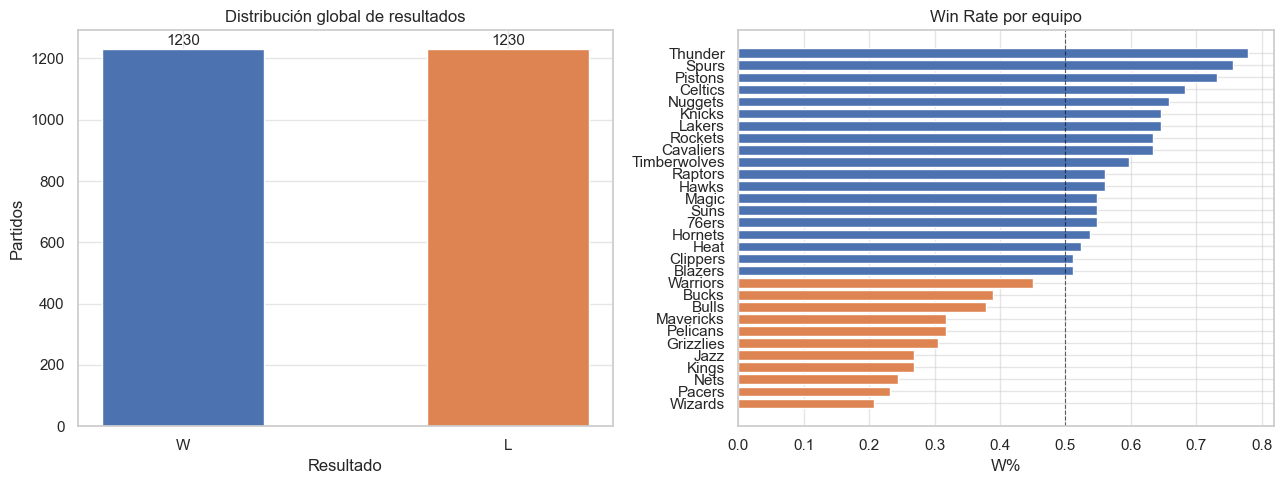

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

wl = team_logs['wl'].value_counts()
axes[0].bar(wl.index, wl.values, color=['#4C72B0', '#DD8452'], width=0.5)
for i, v in enumerate(wl.values):
    axes[0].text(i, v + 15, str(v), ha='center', fontsize=11)
axes[0].set_title('Distribución global de resultados')
axes[0].set_xlabel('Resultado')
axes[0].set_ylabel('Partidos')

ranking = team_season.sort_values('w_pct').copy()
ranking['label'] = ranking['team_name'].str.split().str[-1]
colors = ['#4C72B0' if x >= 0.5 else '#DD8452' for x in ranking['w_pct']]
axes[1].barh(ranking['label'], ranking['w_pct'], color=colors)
axes[1].axvline(0.5, color='black', linestyle='--', linewidth=0.8, alpha=0.6)
axes[1].set_title('Win Rate por equipo')
axes[1].set_xlabel('W%')

plt.tight_layout()
plt.show()

El balance entre victorias y derrotas es exacto: 1.230 de cada tipo (50% / 50%). Esto es correcto por construcción de la liga: cada partido produce exactamente un ganador y un perdedor. No existe desbalance de clases en la variable objetivo de clasificación, lo que permite usar accuracy como métrica directa sin necesidad de ajuste de pesos de clase.

Sin embargo, a nivel de equipo individual los win rates van del 20.7% al 78%. La desviación estándar de 16.9 puntos porcentuales confirma que el rendimiento histórico de un equipo tiene señal predictiva real: el mejor equipo gana casi 4 de cada 5 partidos y el peor menos de 1 de cada 4.

## Variable objetivo — Regresión

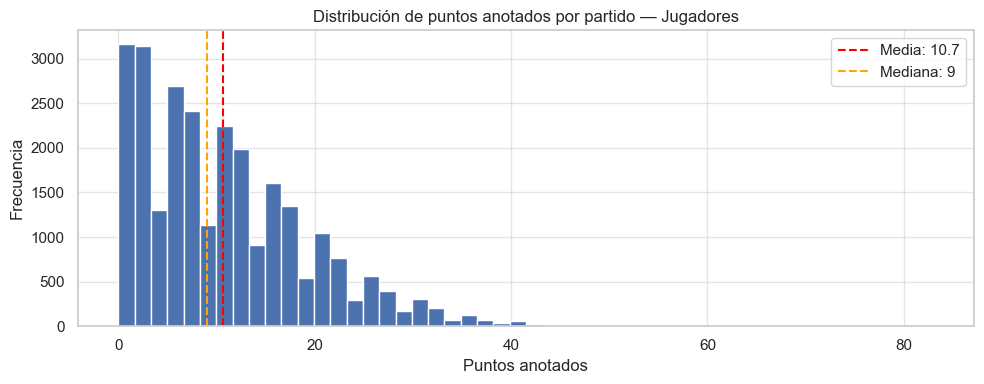

In [13]:
mean_pts   = player_logs['pts'].mean()
median_pts = player_logs['pts'].median()

fig, ax = plt.subplots(figsize=(10, 4))
player_logs['pts'].hist(bins=50, ax=ax, color='#4C72B0', edgecolor='white')
ax.axvline(mean_pts,   color='red',    linestyle='--', linewidth=1.5, label=f'Media: {mean_pts:.1f}')
ax.axvline(median_pts, color='orange', linestyle='--', linewidth=1.5, label=f'Mediana: {median_pts:.0f}')
ax.set_title('Distribución de puntos anotados por partido — Jugadores')
ax.set_xlabel('Puntos anotados')
ax.set_ylabel('Frecuencia')
ax.legend()
plt.tight_layout()
plt.show()

In [14]:
pd.DataFrame({
    'condicion': ['pts == 0', 'pts 1-9', 'pts 10-29', 'pts >= 30'],
    'partidos': [
        (player_logs['pts'] == 0).sum(),
        player_logs['pts'].between(1, 9).sum(),
        player_logs['pts'].between(10, 29).sum(),
        (player_logs['pts'] >= 30).sum()
    ]
}).set_index('condicion').assign(
    pct=lambda x: (x['partidos'] / len(player_logs) * 100).round(1)
)

,partidos,pct
condicion,,
pts == 0,2942,11.0
pts 1-9,10904,40.9
pts 10-29,11861,44.5
pts >= 30,944,3.5


La diferencia entre la media (10.7) y la mediana (9) cuantifica el sesgo positivo de la distribución. El 11% de los registros corresponde a partidos con 0 puntos anotados: son estadísticamente válidos (jugadores con minutos que no anotaron) y se conservarán en el conjunto de entrenamiento.

Los registros con 30 o más puntos representan la cola de alto rendimiento de titulares y estrellas. El máximo de 83 puntos corresponde a una actuación excepcional de la temporada. Estos valores son reales y se mantendrán. Para modelos lineales se evaluará la transformación log(pts + 1) si los residuos muestran patrones sistemáticos. Para modelos basados en árboles, la distribución original es aceptable sin transformaciones.

## Correlaciones

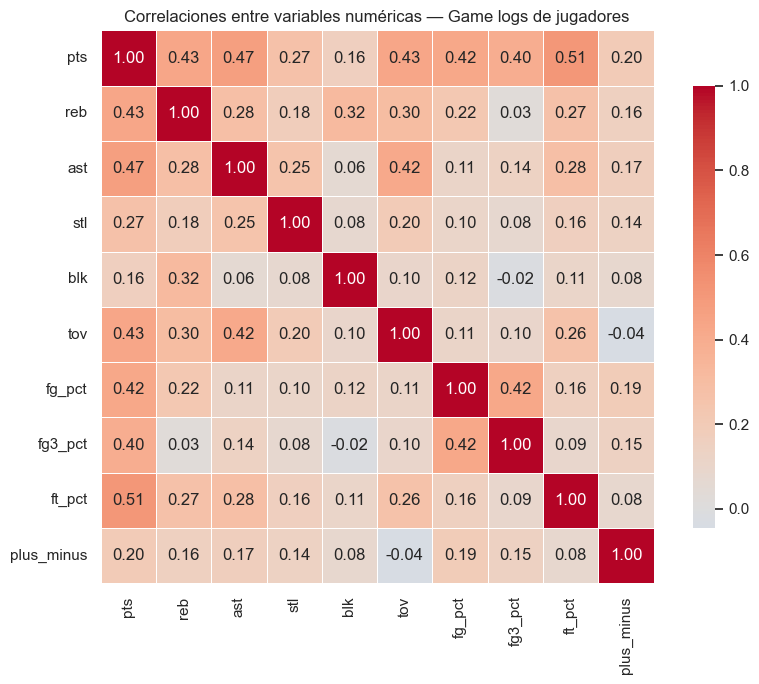

In [15]:
num_cols = ['pts', 'reb', 'ast', 'stl', 'blk', 'tov',
            'fg_pct', 'fg3_pct', 'ft_pct', 'plus_minus']
corr = player_logs[num_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8}, ax=ax)
ax.set_title('Correlaciones entre variables numéricas — Game logs de jugadores')
plt.tight_layout()
plt.show()

La variable más correlacionada con `pts` es `ft_pct` (r = 0.511). Esto refleja que los jugadores que van frecuentemente a la línea de tiro libre tienden a ser los de mayor uso y, por tanto, los que más anotan. Le siguen `ast` (r = 0.475), `reb` (r = 0.431) y `tov` (r = 0.429).

La correlación positiva de `tov` con `pts` puede parecer contraintuitiva, pero refleja que los jugadores con más posesiones —y por tanto más puntos— también cometen más pérdidas de balón. Es una correlación de uso, no de eficiencia.

`blk` tiene la correlación más baja con `pts` (r = 0.160), lo que tiene sentido: los especialistas defensivos y pívots protectores no suelen ser los máximos anotadores.

`plus_minus` tiene una correlación moderada con `pts` (r = 0.200), lo que indica que el aporte individual en puntos explica solo una parte del resultado colectivo del partido.

## Análisis temporal

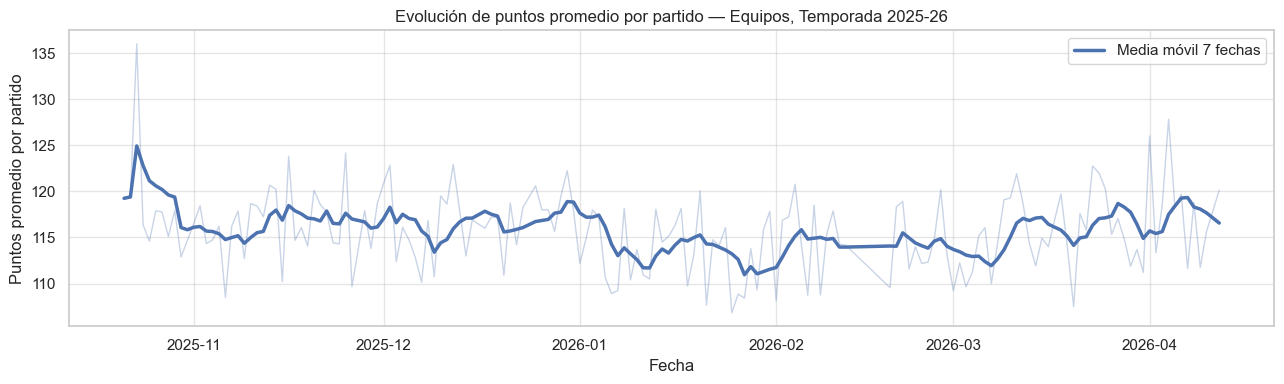

In [16]:
temporal = team_logs.groupby('game_date')['pts'].mean().sort_index()
rolling  = temporal.rolling(7, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(temporal.index, temporal.values, alpha=0.3, color='#4C72B0', linewidth=1)
ax.plot(temporal.index, rolling.values,  color='#4C72B0', linewidth=2.5,
        label='Media móvil 7 fechas')
ax.set_xlabel('Fecha')
ax.set_ylabel('Puntos promedio por partido')
ax.set_title('Evolución de puntos promedio por partido — Equipos, Temporada 2025-26')
ax.legend()
plt.tight_layout()
plt.show()

El promedio de puntos por partido oscila a lo largo de la temporada sin tendencias estructurales marcadas. La media móvil de 7 fechas estabiliza los picos producidos por días con pocos partidos programados, revelando una línea base relativamente constante alrededor de los 115 puntos.

Esta estabilidad temporal es relevante para el diseño de features: no es necesario aplicar correcciones por tendencia. Una ventana de los últimos 5 a 10 partidos captura el estado de forma reciente de un equipo o jugador con suficiente señal, sin acumular ruido de partidos muy anteriores.

## Conclusiones del EDA

**1.** Los cuatro datasets no contienen valores nulos ni duplicados. Los datos provienen directamente de la API oficial de la NBA y pueden pasar a la fase de preparación sin limpieza estructural previa.

**2.** La variable objetivo de clasificación (W/L) está perfectamente balanceada: 1.230 victorias y 1.230 derrotas. No se requieren técnicas de balanceo de clases como SMOTE ni ajuste de `class_weight`. Sin embargo, a nivel de equipo individual los win rates van del 20.7% al 78%, lo que confirma que hay señal predictiva real que modelar.

**3.** El 11% de los registros de jugadores tiene 0 puntos anotados. Son registros válidos y se conservarán. La distribución de PTS es fuertemente sesgada a la derecha: para modelos lineales se evaluará la transformación log(pts + 1); para modelos basados en árboles no es necesaria.

**4.** Las variables más correlacionadas con `pts` son `ft_pct` (r = 0.511), `ast` (r = 0.475) y `reb` (r = 0.431). Estas tres serán candidatas prioritarias como features en el modelo de regresión. La correlación positiva de `tov` con `pts` (r = 0.429) refleja el efecto de uso, no de ineficiencia.

**5.** `ft_pct` y `fg3_pct` tienen medias comprimidas por incluir partidos con cero intentos en esa categoría. Al construir promedios móviles en el notebook 03, se calculará el porcentaje solo sobre partidos con intentos, o se complementará con el volumen de intentos como feature separada.

**6.** `plus_minus` es simétrico alrededor de 0 (media = 0.000, desv = 11.9). Como feature para clasificación puede capturar si un equipo ha estado ganando o perdiendo por márgenes amplios en sus partidos recientes, lo que lo convierte en un candidato relevante para las ventanas temporales del modelo de equipo.

**7.** La evolución temporal de puntos a lo largo de la temporada es estable, sin tendencias estructurales. El diseño de features con ventanas de 5 a 10 partidos previos es metodológicamente apropiado y no requiere ajustes por deriva temporal.